In [101]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

In [3]:
def make_complex(real, imag):
    return np.array(real) + 1j * np.array(imag)

In [30]:
def parse_dat(filename: str):
    def read_floats(n):
        return [float(f.readline().strip()) for _ in range(n)]

    def read_header():
        header = f.readline().strip().split()
        r, B, K, nf = header
        r, K, nf = int(r), int(K), int(nf)
        B = float(B)
        return r, B, K, nf

    def read_ij():
        i, j = map(int, f.readline().strip().split())
        return i, j

    with open(filename, 'r') as f:
        r, B, K, nf = read_header()

        S_hat = np.zeros((nf, r, r), dtype=complex)

        f.readline()
        frequencies = np.array(read_floats(nf))
        f.readline()

        for _ in range(r * (r + 1) // 2):
            i, j = read_ij()

            real = read_floats(nf)
            f.readline()
            imag = read_floats(nf)

            comp = make_complex(real, imag)
            S_hat[:, i - 1, j - 1] = comp
            S_hat[:, j - 1, i - 1] = comp
        return B, K, frequencies, S_hat


In [31]:
B, K, frequencies, S_hat = parse_dat("SDM_1.dat")
nf, _, r = S_hat.shape

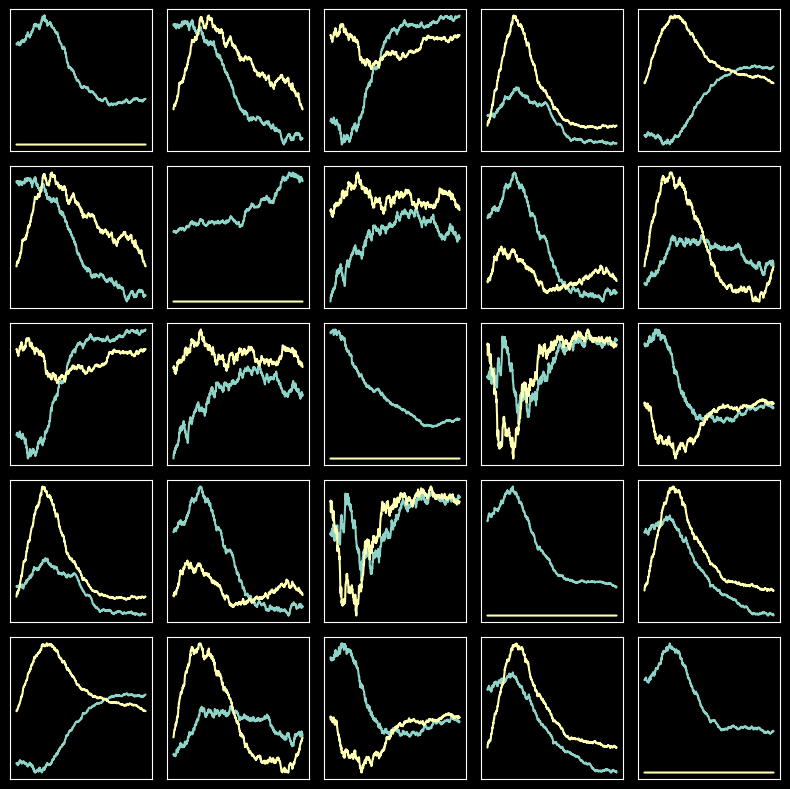

In [32]:
fig, axs = plt.subplots(r, r, figsize=(8, 8), tight_layout=True)

for i in range(r):
    for j in range(r):
        axs[i, j].plot(S_hat[:, i, j].real)
        axs[i, j].plot(S_hat[:, i, j].imag)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])

In [33]:
frequency_grid_mask = np.logical_and(
    B / 2 <= frequencies,
    frequencies <= 0.5 - B / 2
)

frequency_grid = frequencies[frequency_grid_mask]
A = len(frequency_grid)

In [113]:
S_hat_inv = np.linalg.inv(S_hat)
S_hat_inv_diag = S_hat_inv.diagonal(axis1=1, axis2=2)

In [110]:
partial_coherence = np.abs(S_hat_inv ** 2) / (S_hat_inv_diag[:, :, None] * S_hat_inv_diag[:, None, :])

In [94]:
W = -2 * K * np.log(1 - partial_coherence[frequency_grid_mask]).sum(axis=0)
W

/var/folders/78/bkcwr2f5395cy1zsrtqv9ryh0000gn/T/ipykernel_44108/3362093381.py:1: RuntimeWarning: divide by zero encountered in log
  W = -2 * K * np.log(1 - partial_correlation[frequency_grid_mask]).sum(axis=0)


array([[           inf, 43060.30043869, 14485.26908339, 30793.04861842,
        21035.97650863],
       [43060.30043869,            inf,  8389.45923972, 66520.0455553 ,
        11581.04759402],
       [14485.26908339,  8389.45923972,            inf,  5162.30994261,
         7367.69339483],
       [30793.04861842, 66520.0455553 ,  5162.30994261,            inf,
        83879.36320324],
       [21035.97650863, 11581.04759402,  7367.69339483, 83879.36320324,
                   inf]])